# 와인 품질 회귀분석 — 재검증

**원본**: 2023년 회귀분석 조별과제 (UCI Wine Quality, 적포도주 1,599건)
**재검증**: 2026-09-08

원본 분석은 노트북 5개에 흩어져 있고, 보고서에 적힌 결론 중 일부가 데이터와 맞지 않는다.
이 노트북은 원본을 대체하지 않는다. **원본이 무엇을 주장했는지 확인하고, 그 주장이 데이터에서 성립하는지 다시 재는 것**이 목적이다.

검증 대상 4가지:

| # | 원본의 주장 | 결과 |
|---|---|---|
| 1 | `density`가 품질에 가장 큰 영향 (계수 −10.35) | §4 |
| 2 | `density`~`residual sugar` 고상관이 핵심 이슈 | §3 |
| 3 | 다중공선성 처리가 이 분석의 핵심 과제 | §3 |
| 4 | RandomForest R² = 1.0 | §5 |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import cross_val_score, KFold, GroupKFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.width', 120)
RANDOM_STATE = 42
CV = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print('준비 완료')

준비 완료


## 1. 데이터 로드

UCI Machine Learning Repository — [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).
원본 CSV는 공개 데이터라 저장소에 포함하지 않는다 (`.gitignore`). 위 링크에서 받아 `wine+quality/` 에 두면 실행된다.

**적포도주(red)와 백포도주(white)를 모두 읽는다.** §3에서 필요하다.

In [2]:
red   = pd.read_csv('wine+quality/winequality-red.csv',   sep=';')
white = pd.read_csv('wine+quality/winequality-white.csv', sep=';')

print(f'red   {red.shape}')
print(f'white {white.shape}')
print(f'\n결측치 — red: {red.isnull().sum().sum()}개, white: {white.isnull().sum().sum()}개')
red.head(3)

red   (1599, 12)
white (4898, 12)

결측치 — red: 0개, white: 0개


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


## 2. 진단 — 원본이 확인하지 않은 것

결측치는 없다. 원본 분석도 이것은 확인했다. 확인하지 않은 것이 하나 있다.

In [3]:
dup_red   = red.duplicated().sum()
dup_white = white.duplicated().sum()
print(f'완전 중복 행 — red: {dup_red}행 ({dup_red/len(red)*100:.1f}%),  white: {dup_white}행 ({dup_white/len(white)*100:.1f}%)')
print(f'red 고유 조합: {len(red.drop_duplicates())}행 / 전체 {len(red)}행')

print('\n등급 분포:')
dist = red['quality'].value_counts().sort_index()
print(pd.DataFrame({'건수': dist, '비율(%)': (dist/len(red)*100).round(1)}).to_string())
print(f"\n5~6등급이 전체의 {dist[[5,6]].sum()/len(red)*100:.1f}%")

완전 중복 행 — red: 240행 (15.0%),  white: 937행 (19.1%)
red 고유 조합: 1359행 / 전체 1599행

등급 분포:
          건수  비율(%)
quality            
3         10    0.6
4         53    3.3
5        681   42.6
6        638   39.9
7        199   12.4
8         18    1.1

5~6등급이 전체의 82.5%


11개 측정값이 소수점까지 전부 같은 행이 **240행(15.0%)** 있다.

ID 컬럼이 없어서 이것이 입력 오류인지, 같은 배치에서 나온 서로 다른 병인지 **데이터만으로는 판정할 수 없다**.
그래서 제거 여부를 단정하지 않고, §6에서 제거했을 때와 안 했을 때를 모두 측정한다.

등급은 3~8의 **이산 서열값**이고 5~6등급에 82.5%가 몰려 있다. 이 점은 §7에서 다시 다룬다.

## 3. 주장 검증 ① — "density ~ residual sugar 고상관"과 다중공선성

원본 보고서는 `density`와 `residual sugar`의 강한 상관을 이 분석의 핵심 이슈로 들고,
다중공선성 처리를 주요 과제로 서술한다. 실제로 그런지 두 데이터셋에서 같이 잰다.

In [4]:
pair = ('density', 'residual sugar')
print(f"{pair[0]} ~ {pair[1]} 상관계수")
print(f"  red   : {red[list(pair)].corr().iloc[0,1]:+.3f}")
print(f"  white : {white[list(pair)].corr().iloc[0,1]:+.3f}   \u2190 보고서가 서술한 값과 일치")

def top_pairs(df, n=4):
    c = df.drop(columns='quality').corr().abs()
    m = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
    return m.head(n)

print('\n[red] 변수 간 상관 상위 4쌍');   print(top_pairs(red).round(3).to_string())
print('\n[white] 변수 간 상관 상위 4쌍'); print(top_pairs(white).round(3).to_string())

density ~ residual sugar 상관계수
  red   : +0.355
  white : +0.839   ← 보고서가 서술한 값과 일치

[red] 변수 간 상관 상위 4쌍
fixed acidity        pH                      0.683
                     citric acid             0.672
                     density                 0.668
free sulfur dioxide  total sulfur dioxide    0.668

[white] 변수 간 상관 상위 4쌍
residual sugar        density                 0.839
density               alcohol                 0.780
free sulfur dioxide   total sulfur dioxide    0.616
total sulfur dioxide  density                 0.530


`density ~ residual sugar` 상관은 **적포도주에서 +0.355(약함), 백포도주에서 +0.839(매우 강함)**이다.

원본은 적포도주를 분석했는데, 보고서가 핵심 이슈로 서술한 상관 구조는 **백포도주의 특성**이다.
두 CSV를 함께 열어보다 서술이 섞인 것으로 보인다.

그렇다면 적포도주에 다중공선성 문제가 실제로 있는가? VIF로 잰다.

In [5]:
X_red = red.drop(columns='quality'); y_red = red['quality']
Xc = sm.add_constant(X_red)
vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
                index=X_red.columns).sort_values(ascending=False)
print('VIF (적포도주)'); print(vif.round(2).to_string())
print(f'\n최대 VIF = {vif.max():.2f}  (통상 기준 10 초과 시 문제)')
print('10 초과 변수:', list(vif[vif > 10].index) or '없음')

VIF (적포도주)
fixed acidity           7.77
density                 6.34
pH                      3.33
citric acid             3.13
alcohol                 3.03
total sulfur dioxide    2.19
free sulfur dioxide     1.96
volatile acidity        1.79
residual sugar          1.70
chlorides               1.48
sulphates               1.43

최대 VIF = 7.77  (통상 기준 10 초과 시 문제)
10 초과 변수: 없음


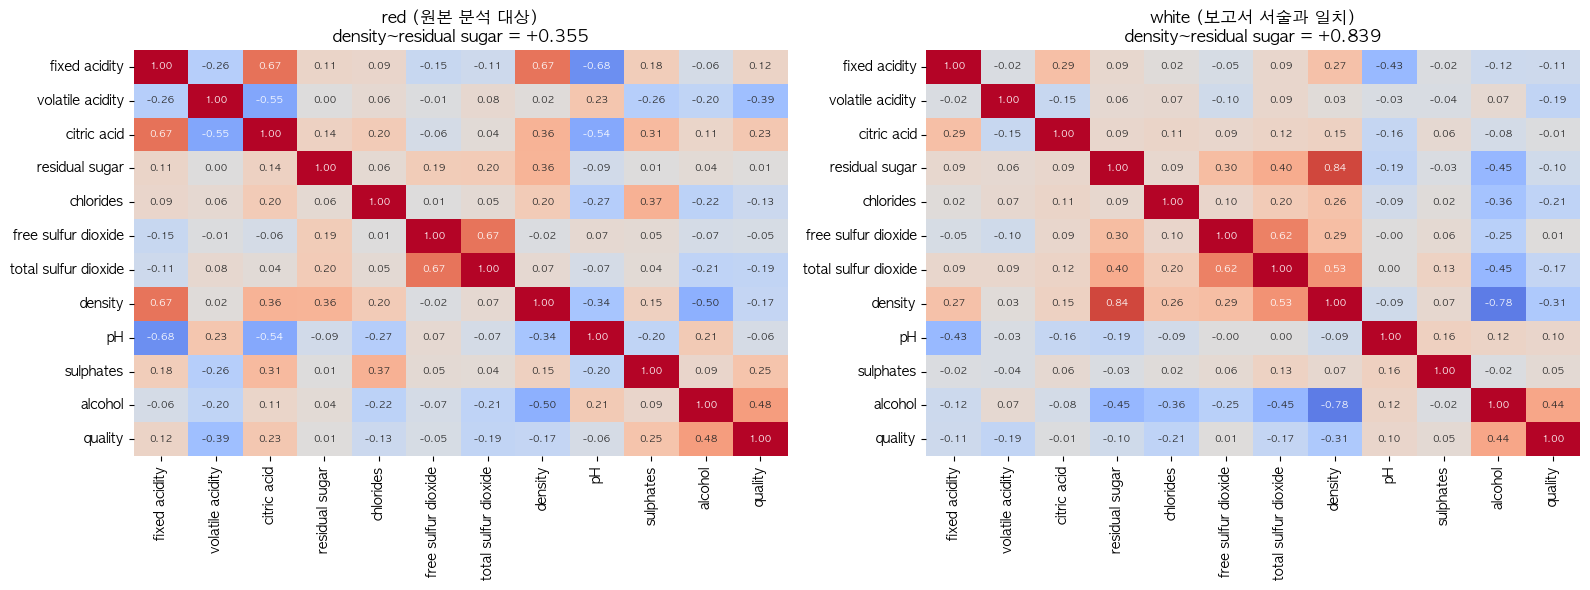

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, df_) in zip(axes, [('red (원본 분석 대상)', red), ('white (보고서 서술과 일치)', white)]):
    sns.heatmap(df_.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, cbar=False, annot_kws={'size': 7})
    ax.set_title(f'{name}\ndensity~residual sugar = {df_["density"].corr(df_["residual sugar"]):+.3f}')
plt.tight_layout(); plt.show()

**결론 ①**: 적포도주의 최대 VIF는 `fixed acidity` 7.77로 통상 기준 10을 넘지 않는다.
다중공선성은 이 분석의 핵심 과제가 아니었다. 핵심 과제로 서술된 근거(`density~residual sugar`)는 다른 데이터셋의 것이다.

## 4. 주장 검증 ② — "density가 품질에 가장 큰 영향"

원본은 회귀계수의 절대값 크기로 영향력을 판단했다. 계수 표를 그대로 재현한다.

> 원본 보고서의 계수(`density` −10.35 등)는 80/20 **분할** 적합값이고, 아래는 **전수** 적합값이라
> 숫자가 조금씩 다르다(density −17.88, chlorides −1.87 …). 순위와 결론은 동일하다.

In [7]:
ols = sm.OLS(y_red, sm.add_constant(X_red)).fit()
print(f'R² = {ols.rsquared:.4f}   Adj.R² = {ols.rsquared_adj:.4f}   F = {ols.fvalue:.2f}   N = {int(ols.nobs)}')

Xs = pd.DataFrame(StandardScaler().fit_transform(X_red), columns=X_red.columns)
ols_s = sm.OLS(y_red, sm.add_constant(Xs)).fit()

tab = pd.DataFrame({
    '원계수': ols.params[X_red.columns],
    'p값': ols.pvalues[X_red.columns],
    '표준화계수': ols_s.params[X_red.columns],
    '변수 표준편차': X_red.std(),
})
tab['유의(p<.05)'] = np.where(tab['p값'] < 0.05, '○', '✗')
tab['원계수 순위']   = tab['원계수'].abs().rank(ascending=False).astype(int)
tab['표준화 순위']   = tab['표준화계수'].abs().rank(ascending=False).astype(int)
print()
print(tab.sort_values('원계수 순위').round(4).to_string())

R² = 0.3606   Adj.R² = 0.3561   F = 81.35   N = 1599

                          원계수      p값   표준화계수  변수 표준편차 유의(p<.05)  원계수 순위  표준화 순위
density              -17.8812  0.4086 -0.0337   0.0019         ✗       1      10
chlorides             -1.8742  0.0000 -0.0882   0.0471         ○       2       5
volatile acidity      -1.0836  0.0000 -0.1940   0.1791         ○       3       2
sulphates              0.9163  0.0000  0.1553   0.1695         ○       4       3
pH                    -0.4137  0.0310 -0.0638   0.1544         ○       5       6
alcohol                0.2762  0.0000  0.2942   1.0657         ○       6       1
citric acid           -0.1826  0.2150 -0.0356   0.1948         ✗       7       9
fixed acidity          0.0250  0.3357  0.0435   1.7411         ✗       8       8
residual sugar         0.0163  0.2765  0.0230   1.4099         ✗       9      11
free sulfur dioxide    0.0044  0.0447  0.0456  10.4602         ○      10       7
total sulfur dioxide  -0.0033  0.0000 -0.1074  32.8953 

변수들의 단위가 제각각이다. `density`의 표준편차는 **0.0019**, `total sulfur dioxide`는 **32.9** — 만 배 이상 차이난다.
단위가 다른 계수의 절대값을 비교하면 **작은 단위를 쓰는 변수가 자동으로 커 보인다**. 표준화해서 다시 비교한다.

표준화 후 영향력 순위
                      원계수 순위  표준화 순위   표준화계수      p값 유의(p<.05)
alcohol                    6       1  0.2942  0.0000         ○
volatile acidity           3       2 -0.1940  0.0000         ○
sulphates                  4       3  0.1553  0.0000         ○
total sulfur dioxide      11       4 -0.1074  0.0000         ○
chlorides                  2       5 -0.0882  0.0000         ○
pH                         5       6 -0.0638  0.0310         ○
free sulfur dioxide       10       7  0.0456  0.0447         ○
fixed acidity              8       8  0.0435  0.3357         ✗
citric acid                7       9 -0.0356  0.2150         ✗
density                    1      10 -0.0337  0.4086         ✗
residual sugar             9      11  0.0230  0.2765         ✗


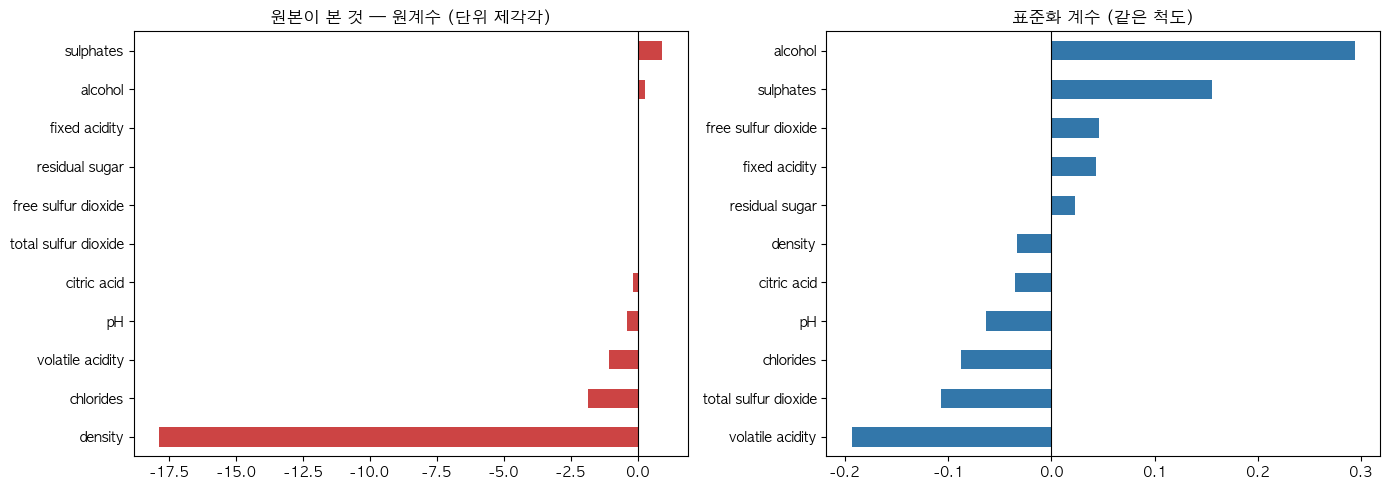


density — 원계수 -17.88 (크기 1위)  →  표준화 -0.034 (10위),  p = 0.409
p>0.05 인 변수: ['fixed acidity', 'citric acid', 'residual sugar', 'density']


In [8]:
comp = tab[['원계수 순위', '표준화 순위', '표준화계수', 'p값', '유의(p<.05)']].sort_values('표준화 순위')
print('표준화 후 영향력 순위'); print(comp.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tab['원계수'].sort_values().plot.barh(ax=axes[0], color='#c44')
axes[0].set_title('원본이 본 것 — 원계수 (단위 제각각)'); axes[0].axvline(0, c='k', lw=.8)
tab['표준화계수'].sort_values().plot.barh(ax=axes[1], color='#37a')
axes[1].set_title('표준화 계수 (같은 척도)'); axes[1].axvline(0, c='k', lw=.8)
plt.tight_layout(); plt.show()

d = tab.loc['density']
print(f"\ndensity — 원계수 {d['원계수']:.2f} (크기 {int(d['원계수 순위'])}위)  →  "
      f"표준화 {d['표준화계수']:+.3f} ({int(d['표준화 순위'])}위),  p = {d['p값']:.3f}")
print('p>0.05 인 변수:', [c for c in X_red.columns if ols.pvalues[c] > 0.05])

**결론 ②**: `density`의 계수가 가장 큰 것은 영향력이 커서가 아니라 **단위가 가장 작아서**다.

같은 척도로 놓으면 `density`는 11개 중 **10위**이고, **p = 0.409로 통계적으로 유의하지 않다**.
`citric acid`, `residual sugar`, `fixed acidity`도 마찬가지로 유의하지 않다.

실제 영향력 순위는 **alcohol(+0.294) > volatile acidity(−0.194) > sulphates(+0.155)** 이다.
원본이 "품질에 가장 큰 영향"으로 지목한 변수는 유의하지 않은 변수였다.

## 5. 주장 검증 ③ — RandomForest R² = 1.0의 원인

원본 `wine.ipynb` 마지막 셀의 출력은 다음과 같다.

```
MSE: 0.0
R2 Score: 1.0
                      Importance
volatile acidity             0.0
citric acid                  0.0
...
alcohol                      0.0
quality                      1.0     ← 정답이 특성에 들어있다
```

중요도 표의 **인덱스가 `volatile acidity`에서 시작해 `quality`로 끝난다**.
즉 학습에 쓰인 특성 행렬은 `fixed acidity`를 뺀 11열이었고, 그 안에 **예측 대상인 `quality`가 포함**되어 있었다.

같은 노트북 앞쪽 셀은 `X = red_wine_data.drop('quality', axis=1)` 로 올바르게 정의한다.
**이 행렬을 만든 코드는 어느 노트북에도 남아 있지 않다** (`fixed acidity` 제거, `.iloc` 슬라이싱, 컬럼 목록 지정 모두 검색해 확인).

노트북이 저장된 상태 자체가 어긋나 있다는 정황은 있다 — 실행 카운트가 셀 1(=7)과 셀 8(=3)에만 남아 있고
나머지 셀은 전부 `null`인데도 출력은 갖고 있다. **저장 시점의 셀 구성이 실행 시점과 달랐다**는 뜻이다.
다만 `X`가 정확히 어떻게 만들어졌는지는 **확정하지 못했다.** 확인할 수 있는 것은 결과뿐이다 — 정답이 특성에 들어 있었다.

재현해서 확인한다.

In [9]:
# 원본이 실제로 학습한 것으로 보이는 행렬: quality 포함, fixed acidity 제외
X_leak = red.drop(columns='fixed acidity')
Xtr, Xte, ytr, yte = train_test_split(X_leak, y_red, test_size=0.2, random_state=RANDOM_STATE)
rf_leak = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(Xtr, ytr)
pred = rf_leak.predict(Xte)

print(f'MSE = {mean_squared_error(yte, pred)}')
print(f'R²  = {r2_score(yte, pred)}')
print('\n특성 중요도:')
print(pd.Series(rf_leak.feature_importances_, index=X_leak.columns).round(3).to_string())

MSE = 0.0
R²  = 1.0

특성 중요도:
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 1.0


**결론 ③**: 원본 출력이 그대로 재현된다. MSE 0.0, R² 1.0, `quality` 중요도 1.0, 나머지 전부 0.0.

모델은 아무것도 학습하지 않았다. **정답을 그대로 베껴서 답한 것**이다.
숲의 모든 트리가 `quality` 하나로 완전히 갈라지므로 다른 변수는 쓸 일이 없어 중요도가 0이 된다.

이것은 성능이 아니라 **타깃 누수(target leakage)**이며, R² = 1.0은 무효다.

## 6. 중복 240행이 만드는 폴드 간 누수

§2에서 미룬 문제다. 중복 행은 교차검증에서 **같은 행이 훈련과 테스트에 동시에 들어갈 수 있다**.
그러면 모델은 답을 외워서 맞힐 수 있다. 얼마나 일어나는지 센다.

In [10]:
grp = red.groupby(list(red.columns), sort=False).ngroup()   # 동일 행끼리 같은 그룹
leaked = sum(grp.iloc[te].isin(set(grp.iloc[tr]) & set(grp.iloc[te])).sum()
             for tr, te in CV.split(X_red))
print(f'고유 조합 {grp.nunique()}개 / 전체 {len(red)}행')
print(f'테스트 폴드에 있으면서 훈련 폴드에도 동일한 행이 존재: {leaked}행 ({leaked/len(red)*100:.1f}%)')

고유 조합 1359개 / 전체 1599행
테스트 폴드에 있으면서 훈련 폴드에도 동일한 행이 존재: 386행 (24.1%)


In [11]:
models = {'OLS': LinearRegression(),
          'RandomForest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)}
rows = []
for name, m in models.items():
    a = cross_val_score(m, X_red, y_red, cv=CV, scoring='r2')
    b = cross_val_score(m, X_red, y_red, cv=GroupKFold(5), scoring='r2', groups=grp)
    rows.append({'모델': name, '일반 KFold': f'{a.mean():+.3f} ± {a.std():.3f}',
                 'GroupKFold(중복 분리)': f'{b.mean():+.3f} ± {b.std():.3f}',
                 '차이': f'{b.mean()-a.mean():+.3f}'})
print(pd.DataFrame(rows).to_string(index=False))

          모델       일반 KFold GroupKFold(중복 분리)     차이
         OLS +0.342 ± 0.064    +0.334 ± 0.076 -0.009
RandomForest +0.493 ± 0.026    +0.364 ± 0.068 -0.129


테스트 행의 **24.1%**가 훈련 쪽에 똑같은 쌍둥이를 갖고 있다.

중복을 분리하면 **RandomForest는 R²가 0.129 떨어지고, OLS는 0.009밖에 안 떨어진다**.
선형모델은 개별 행을 외울 수 없어서 영향이 없고, 트리 모델만 외운 만큼을 잃는다.

즉 RandomForest가 OLS보다 크게 앞서 보이던 차이의 상당 부분은 **성능이 아니라 중복 행을 외운 것**이었다.

## 7. 모델 사다리

원본은 선형회귀와 (무효인) RandomForest만 비교했다. 기준선부터 쌓아 올린다.

- **① 평균 예측** — 아무것도 학습하지 않는 하한선. R² ≈ 0
- **② alcohol 단일 회귀** — 품질과 상관이 가장 높은(+0.476) 변수 하나
- **③ 전체 11변수 OLS** — 원본의 모델
- **④ RandomForest** — 정상 학습

In [12]:
red_dedup = red.drop_duplicates()
ladder = [('① 평균 예측(Dummy)', DummyRegressor(strategy='mean'), None),
          ('② alcohol 단일 OLS', LinearRegression(), ['alcohol']),
          ('③ 전체 11변수 OLS',  LinearRegression(), None),
          ('④ RandomForest',    RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), None)]

def cv_r2(m, d, cols):
    X = d.drop(columns='quality') if cols is None else d[cols]
    s = cross_val_score(m, X, d['quality'], cv=CV, scoring='r2')
    return s.mean(), s.std()

rows = []
for name, m, cols in ladder:
    a, sa = cv_r2(m, red, cols)
    b, sb = cv_r2(m, red_dedup, cols)
    rows.append({'모델': name,
                 '원본 1,599행': f'{a:+.3f} ± {sa:.3f}',
                 '중복 행 제거 1,359행': f'{b:+.3f} ± {sb:.3f}'})
res = pd.DataFrame(rows)
print('5-fold 교차검증 R²'); print(res.to_string(index=False))

alc, _  = cv_r2(LinearRegression(), red, ['alcohol'])
full, _ = cv_r2(LinearRegression(), red, None)
print(f'\nalcohol 한 변수가 전체 11변수 모델 성능의 {alc/full*100:.0f}%를 설명한다')

5-fold 교차검증 R²
              모델      원본 1,599행 중복 행 제거 1,359행
  ① 평균 예측(Dummy) -0.002 ± 0.003 -0.003 ± 0.003
② alcohol 단일 OLS +0.224 ± 0.061 +0.228 ± 0.011
   ③ 전체 11변수 OLS +0.342 ± 0.064 +0.347 ± 0.026
  ④ RandomForest +0.493 ± 0.026 +0.385 ± 0.044

alcohol 한 변수가 전체 11변수 모델 성능의 65%를 설명한다


읽는 법:

- 원본이 보고한 단일 분할 R² **0.403**은 5-fold 평균 **0.342 ± 0.064**보다 높다.
  분할 하나만 보면 폴드마다 ±0.06씩 흔들리는 값 중 운 좋은 쪽을 집은 것이 된다.
- **`alcohol` 하나로 전체 모델의 65%**가 설명된다. 나머지 10개 변수가 더하는 몫은 R² 0.12 정도다.
- 중복을 제거하면 OLS는 그대로(0.342→0.347)지만 RandomForest는 0.493→0.385로 떨어진다 (§6과 같은 이야기).

## 8. 선형회귀의 구조적 한계와 순서형 로지스틱

`quality`는 3~8의 **정수 등급**이다. 선형회귀는 이를 연속값으로 다루므로 5.37 같은 값을 내놓는다.
예측값을 반올림해서 실제로 어떤 등급을 맞히는지 본다.

In [13]:
lin = LinearRegression().fit(X_red, y_red)
raw  = lin.predict(X_red)
pred_lin = np.clip(np.round(raw), 3, 8)

print(f'반올림 전 예측 범위: {raw.min():.2f} ~ {raw.max():.2f}   (실제 등급 범위 3 ~ 8)')
print('\n선형회귀가 실제로 내놓는 등급:')
print(pd.Series(pred_lin).value_counts().sort_index().to_string())
print('\n실제 등급 분포:')
print(y_red.value_counts().sort_index().to_string())

반올림 전 예측 범위: 4.25 ~ 7.47   (실제 등급 범위 3 ~ 8)

선형회귀가 실제로 내놓는 등급:
4.0      5
5.0    709
6.0    807
7.0     78

실제 등급 분포:
quality
3     10
4     53
5    681
6    638
7    199
8     18


선형회귀는 **3, 4, 8등급을 사실상 예측하지 못한다**. 예측이 5와 6에 몰린다.
데이터의 82.5%가 5~6등급이므로 평균 근처로 답하는 것이 제곱오차상 유리하기 때문이다.

등급이 서열을 가진다는 것을 모델에 알려주는 대안이 순서형 로지스틱 회귀다.

In [14]:
ord_m = OrderedModel(y_red, Xs, distr='logit').fit(method='bfgs', disp=False)
print(f'Log-Likelihood = {ord_m.llf:.1f}   Pseudo R² = {ord_m.prsquared:.4f}   AIC = {ord_m.aic:.1f}')
print('\n표준화 계수 (절대값 상위 5):')
print(ord_m.params[X_red.columns].sort_values(key=abs, ascending=False).head(5).round(3).to_string())

pred_ord = np.asarray(ord_m.predict(Xs)).argmax(1) + 3
print('\n등급 정확 일치율')
print(f'  최빈값(5등급)으로 다 찍기 : {(y_red == 5).mean():.3f}')
print(f'  선형회귀 (반올림)        : {(pred_lin == y_red).mean():.3f}')
print(f'  순서형 로지스틱          : {(pred_ord == y_red).mean():.3f}')

Log-Likelihood = -1537.4   Pseudo R² = 0.1884   AIC = 3106.8

표준화 계수 (절대값 상위 5):
alcohol                 0.885
volatile acidity       -0.608
sulphates               0.492
total sulfur dioxide   -0.366
chlorides              -0.242

등급 정확 일치율
  최빈값(5등급)으로 다 찍기 : 0.426
  선형회귀 (반올림)        : 0.592
  순서형 로지스틱          : 0.595


순서형 로지스틱의 정확도(0.595)는 선형회귀 반올림(0.592)과 **사실상 같다**.
모델을 바꿔도 나아지지 않는다 — 한계는 모델이 아니라 **데이터에 5~6등급이 82.5% 몰려 있는 구조**에 있다.

다만 영향력 순위는 두 모델이 일치한다(alcohol > volatile acidity > sulphates). §4의 결론이 모델과 무관하게 유지된다는 뜻이다.

## 9. 결론

### 원본의 네 가지 주장에 대한 판정

| 원본의 주장 | 재검증 결과 |
|---|---|
| `density`가 품질에 가장 큰 영향 (계수 −10.35) | **틀림.** 표준화하면 11개 중 10위, p=0.409로 비유의. 계수가 컸던 건 표준편차가 0.0019로 가장 작기 때문 |
| `density`~`residual sugar` 고상관이 핵심 이슈 | **적포도주 값이 아님.** red +0.355 / white +0.839 — 백포도주 특성을 적포도주 분석에 서술 |
| 다중공선성 처리가 핵심 과제 | **아님.** 최대 VIF 7.77로 기준 10 미만 |
| RandomForest R² = 1.0 | **무효.** `quality`가 특성에 포함된 타깃 누수. 정상 학습 시 0.493, 중복을 폴드로 분리하면 0.364 |

### 확인된 수치

| 항목 | 값 |
|---|---|
| OLS (전체 데이터) | R² 0.361 / Adj 0.356 / F 81.35 / N 1,599 |
| OLS 5-fold CV | R² **0.342 ± 0.064** |
| RandomForest 5-fold CV | R² 0.493 ± 0.026 → 중복을 폴드로 분리(1,599행 유지) **0.364** / 중복 행 제거(1,359행) **0.385** |
| `alcohol` 단일 변수 | R² 0.224 — 전체 모델의 **65%** |
| 유의하지 않은 변수 (p>0.05) | `fixed acidity`, `citric acid`, `residual sugar`, `density` |
| 실제 영향력 1~3위 | alcohol +0.294 / volatile acidity −0.194 / sulphates +0.155 |
| 완전 중복 행 | 240행 (15.0%) — 교차검증 시 테스트의 24.1%가 훈련에 존재 |

### 배운 것

**1. 단위가 다른 계수의 크기를 비교하면 안 된다.**
이 분석의 결론 전체가 여기서 어긋났다. `density`가 1위로 보인 것은 순전히 단위 때문이고, 표준화 한 줄이면 드러나는 문제였다.

**2. R² = 1.0은 축하할 일이 아니라 의심할 일이다.**
중요도가 한 변수에 1.0으로 몰리고 나머지가 전부 0이면, 그 변수가 정답 자체일 가능성부터 확인해야 한다.

**3. 중복 행은 조용히 성능을 부풀린다.**
결측치는 확인했지만 중복은 확인하지 않았다. 그 결과 RandomForest가 실제보다 0.129만큼 좋아 보였고,
선형모델은 멀쩡했기 때문에 비교만으로는 눈치챌 수 없었다.

**4. 남은 한계 — 이 재검증으로도 풀지 못한 것.**
중복 240행이 입력 오류인지 같은 배치의 다른 병인지는 ID 컬럼이 없어 **판정 불가**다.
등급 3·8이 각각 10건·18건뿐이라 극단 등급 예측은 어떤 모델로도 신뢰하기 어렵다.
`quality`가 관능평가 중앙값이라는 점에서, 설명되지 않는 분산의 상당 부분은 평가자 간 차이일 수 있으나 데이터로는 확인할 수 없다.